# Train FishSeg on Colab

The full training run happens here with Colab's GPU. The pipeline itself was
built and verified locally (see `02_pipeline.ipynb`); this notebook
just runs it at full scale.

**Before running:** set Runtime -> Change runtime type -> GPU (T4 or better).

## Setup

In [1]:
import torch

# Check for GPU and use it if available
if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU available: Tesla T4


In [2]:
# Mount Google Drive to reach the uploaded dataset zip.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Pull the project code for src files
!git clone https://github.com/Furqaan09/fish-size-estimation.git
%cd fish-size-estimation

Cloning into 'fish-size-estimation'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 33 (delta 10), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 6.84 MiB | 10.81 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/fish-size-estimation


In [4]:
# Unzip the dataset from Drive into the project's data folder.
import zipfile, os

zip_path = "/content/drive/MyDrive/Segmentation.zip"
target = "/content/fish-size-estimation/data"
os.makedirs(target, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(target)

print("Extracted:", os.listdir(target))

Extracted: ['__MACOSX', 'Segmentation']


Confirm the data loads on this machine before training.

In [5]:
import sys
sys.path.append("/content/fish-size-estimation")

from pathlib import Path
from src.dataset import FishDataset

SEG = Path("/content/fish-size-estimation/data/Segmentation")

ds = FishDataset(SEG / "train.csv", SEG)
print("train examples:", len(ds))

img, msk = ds[0]
print("image:", img.shape, "mask:", msk.shape)

train examples: 310
image: torch.Size([3, 256, 448]) mask: torch.Size([256, 448])


## Build data loaders, model, loss and optimizer

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader

from src.model import build_model
from src.train import train_one_epoch, evaluate

train_ds = FishDataset(SEG / "train.csv", SEG)
val_ds = FishDataset(SEG / "val.csv", SEG)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

model = build_model(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Ready on", device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 175MB/s]


Ready on cuda


## Train

15 epochs maximum, with early stopping. If validation loss does not improve for
3 epochs in a row, training stops. The best model is saved whenever it improves,
so a few worse epochs at the end cannot overwrite it.

In [7]:
MAX_EPOCHS = 15
PATIENCE = 3

history = {"train": [], "val": []}
best_val = float("inf")
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"epoch: {epoch+1}/{MAX_EPOCHS}    train: {train_loss:.4f}  val:{val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"    saved, best val {best_val:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"    no improvement for {epochs_without_improvement} epoch(s)")
        if epochs_without_improvement >= PATIENCE:
            print(f"early stopping at epoch {epoch+1}")
            break

epoch: 1/15    train: 0.3312  val:0.2389
    saved, best val 0.2389


epoch: 2/15    train: 0.1483  val:0.1170
    saved, best val 0.1170


epoch: 3/15    train: 0.0970  val:0.0935
    saved, best val 0.0935


epoch: 4/15    train: 0.0744  val:0.0714
    saved, best val 0.0714


epoch: 5/15    train: 0.0592  val:0.0596
    saved, best val 0.0596


...

epoch: 11/15    train: 0.0249  val:0.0266
    saved, best val 0.0266


epoch: 12/15    train: 0.0212  val:0.0247
    saved, best val 0.0247


epoch: 13/15    train: 0.0187  val:0.0237
    saved, best val 0.0237


epoch: 14/15    train: 0.0168  val:0.0220
    saved, best val 0.0220


epoch: 15/15    train: 0.0150  val:0.0197
    saved, best val 0.0197


## Loss curve

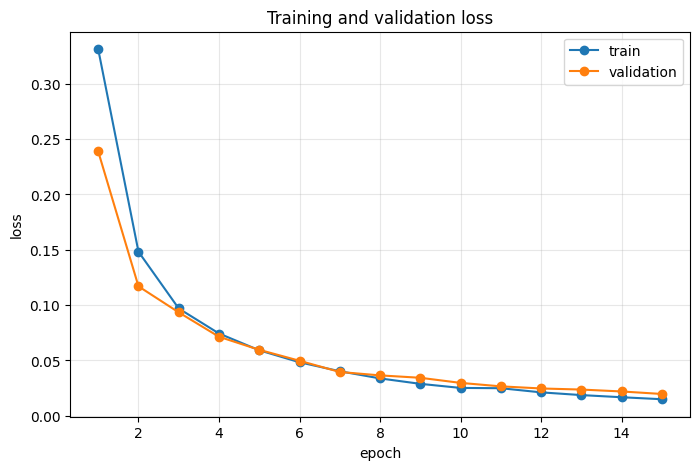

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train"], marker="o", label="train")
plt.plot(epochs, history["val"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## Download

Save the trained weights and the plot.

In [9]:
from google.colab import files
files.download("best_model.pth")
files.download("loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>